Load Neccesary Libraries

In [1]:
# Import Libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit

Read .txt file, then define constants and arrays of physical quantities

In [3]:
# Import .txt files
df = pd.read_csv(f"data/BBO1(more_granular).txt", sep=r"\s+")

# speed of light
c = 299792458

position = df["Position(mm)"]
voltage = df["Voltage(V)"] 
time = 2 * (position / 10**3) / c

# Convert voltage from volts to microvolts (10^-6)
voltage = voltage * 10**6

# Convert time from seconds to picoseconds (10^-12)
time = time * 10**12

Plot voltage w.r.t. position

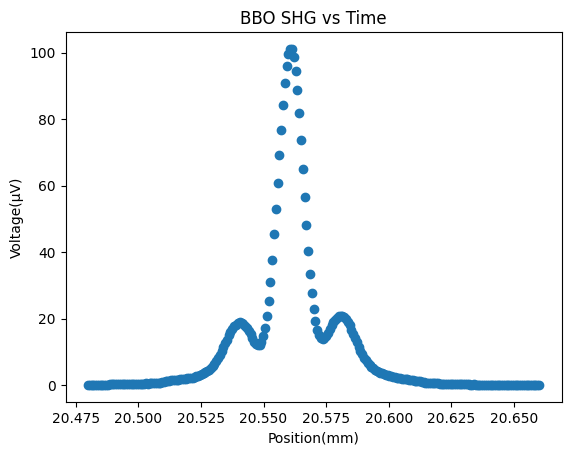

In [5]:
plt.figure()
plt.scatter(position, voltage)
plt.xlabel("Position(mm)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("BBO SHG vs Time")

plt.show()

Plot voltage w.r.t. time

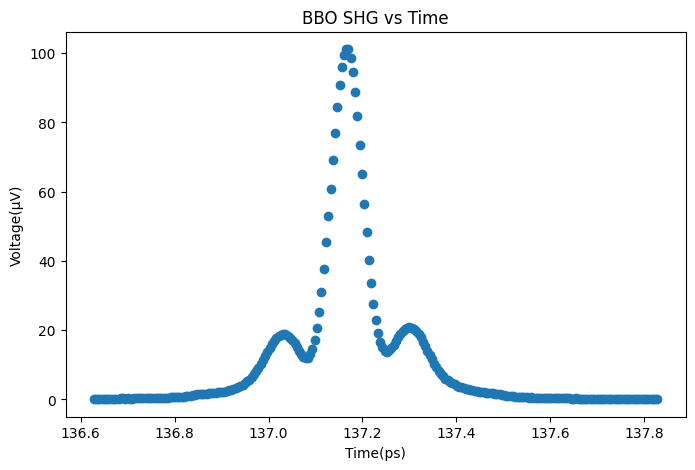

In [6]:

fig = plt.figure(figsize=(8,5))
plt.scatter(time, voltage)
plt.xlabel("Time(ps)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("BBO SHG vs Time")

# fig.savefig(f"BBO_raw_data.pdf", dpi=300, bbox_inches="tight")


plt.show()

**Gaussian Model Fitting**

In [7]:
# Gaussian Model
def gaussian_model(t, A, t0, std):
    return A * np.exp( (-((t - t0) / std)**2) / 2)

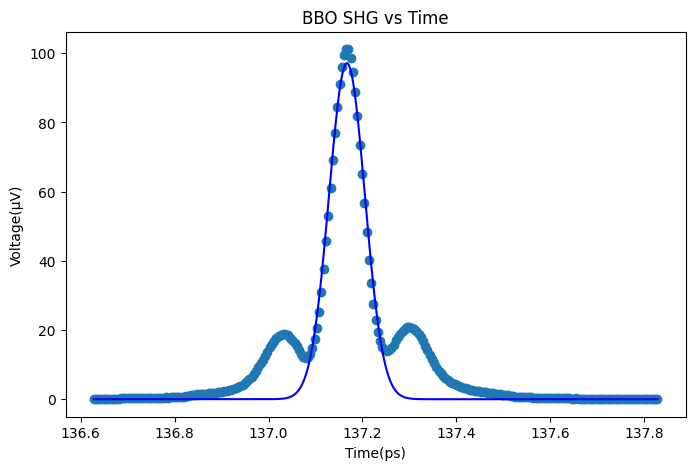

In [28]:
# Fit model to data
p0 = [
    max(voltage),                 # A
    time[np.argmax(voltage)],     # t0
    (max(time) - min(time)) / 10  # std guess
]

params_gauss, _ = curve_fit(gaussian_model, time, voltage, p0=p0)
A_gauss, t0_gauss, std_gauss = params_gauss

t_smooth = np.linspace(time.iloc[0], time.iloc[-1], 500)


# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time, voltage)

# Plot gaussian
plt.plot(
    t_smooth,
    gaussian_model(t_smooth, A_gauss, t0_gauss, std_gauss),
    color = 'blue'
)
plt.xlabel("Time(ps)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("BBO SHG vs Time")

fig.savefig(f"BBO_gaussian_fit.pdf", dpi=300, bbox_inches="tight")


plt.show()

Compute Indices of FWHM, then take the difference to find pulse duration

In [9]:
v_gauss = gaussian_model(t_smooth, A_gauss, t0_gauss, std_gauss)

V_max = np.max(v_gauss)
half = V_max / 2

indices = np.where(v_gauss >= half)[0]
t1 = t_smooth[indices[0]]
t2 = t_smooth[indices[-1]]

pulse_duration = (t2 - t1) * 10**3

print(f"\u0394τ = {pulse_duration} femtoseconds")

print(f"\u0394t = {pulse_duration / np.sqrt(2)} femtoseconds")

Δτ = 86.63307963465172 femtoseconds
Δt = 61.25883808473642 femtoseconds


**Lorentzian Model Fitting**

In [10]:
# Lorentzian Model
def lorentzian_model(t, A, fwhm, t0):
    gamma = fwhm / 2.0
    
    return A * gamma**2 / ((t - t0)**2 + gamma**2)

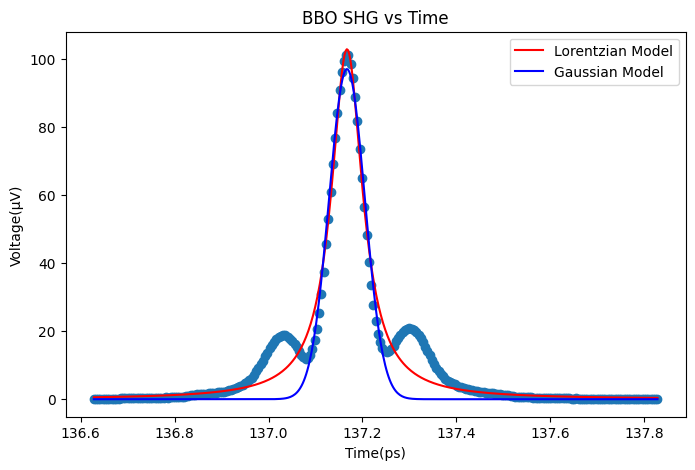

In [40]:
# Plot lorentzian

# Fit model to data
p0 = [
    max(voltage),                 # A
    time[np.argmax(voltage)],     # t0
    (max(time) - min(time)) / 10  # std guess
]

params_lorentz, _ = curve_fit(lorentzian_model, time, voltage, p0 = p0)
A_lorentz, fwhm_lorentz, t0_lorentz = params_lorentz

t_smooth = np.linspace(time.iloc[0], time.iloc[-1], 500)

# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time, voltage)

plt.plot(
    t_smooth,
    lorentzian_model(t_smooth, A_lorentz, fwhm_lorentz, t0_lorentz),
    color = 'red',
    label = "Lorentzian Model"
)
plt.plot(
    t_smooth,
    gaussian_model(t_smooth, A_gauss, t0_gauss, std_gauss),
    color = 'blue',
    label="Gaussian Model"
)

plt.xlabel("Time(ps)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("BBO SHG vs Time")

plt.legend()

fig.savefig(f"BBO_Gaussian_Lorentzian.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
v_loren = lorentzian_model(t_smooth, A_lorentz, fwhm_lorentz, t0_lorentz)

V_max = np.max(v_loren)
half = V_max / 2

indices = np.where(v_loren >= half)[0]
t1 = t_smooth[indices[0]]
t2 = t_smooth[indices[-1]]

pulse_duration = (t2 - t1) * 10**3

print(f"\u0394τ = {pulse_duration} femtoseconds")

print(f"\u0394t = {pulse_duration / np.sqrt(2)} femtoseconds")

Δτ = 77.00718189747136 femtoseconds
Δt = 54.45230051976794 femtoseconds


**Resdiuals**

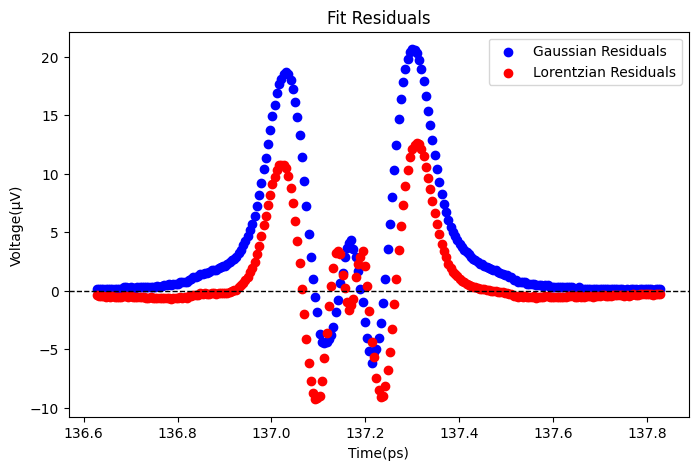

In [47]:
gauss_residuals = voltage - gaussian_model(time, A_gauss, t0_gauss, std_gauss)
lorentz_residuals = voltage - lorentzian_model(time, A_lorentz, fwhm_lorentz, t0_lorentz)

# Create and size figure
fig = plt.figure(figsize=(8,5))

# Plot data
plt.scatter(time, gauss_residuals, color='b', label="Gaussian Residuals")
plt.scatter(time, lorentz_residuals, color='r', label="Lorentzian Residuals")

plt.axhline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel("Time(ps)")
plt.ylabel(f"Voltage(\u00B5V)")
plt.title("Fit Residuals")

plt.legend()

# fig.savefig(f"BBO_residuals.pdf", dpi=300, bbox_inches="tight")


plt.show()
